In [11]:
%reset -f

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt  


import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from scipy.stats import mannwhitneyu


import warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

from pylab import *
pd.set_option('mode.chained_assignment', None)


root_dir = '/Users/weiweizhan/Desktop/Weiwei_Zhan/Projects/WUE'

os.chdir(root_dir)

## Fig 5: dependence on nutrient & water availability 

In [2]:
df_site = pd.read_csv('./Data/results/sites_meta_info.csv',index_col=0)
df_SNR  = pd.read_csv('./Data/results/beta_SNR_results.csv',index_col=0)
df_DI   = pd.read_csv('./Data/results/sites_DI.csv',index_col=0)

df_nutrient = pd.read_csv('./Data/results/sites_nutrient_availability.csv',index_col=0)

df = df_nutrient.merge(df_DI[['DI_Rnet']],left_index=True,right_index=True,how='left')
df = df.loc[df_SNR.index]
df['new_ID'] = df_SNR['new_ID'].values

In [3]:
row_label_dic = {'NP_limitation_NPRE': 'Upscaling (NPRE)',
                 'NP_limitation_ratio':'Upscaling (N:P ratio)',
                 'NP_limitation_insitu':'in-situ',
                 'final':'Nutrient status','NAN':'',
                 'DI_Rnet':'Dryness status'}

cluster_color_dic = {1:'#0072B2',2:'#E69F00',3:'#CC79A7',
                     4:'#56B4E9',5:'#009E73',6:'#F0E442',
                     7:'#D55E00',9999:'black'}  

cluster_new = 'new_ID'

def pre_process(PFT_list,df,row_label_dic=row_label_dic,cluster_new=cluster_new,
                cluster_color_dic=cluster_color_dic,
                columns=['NP_limitation_insitu','NP_limitation_NPRE','NP_limitation_ratio','final','DI_Rnet']):

    mask = df.Cover_type.isin(PFT_list)
    data = df.loc[mask,columns]
    data['NAN'] = np.nan

    columns = columns[:3] + ['NAN'] + columns[3:]
    data = data[columns]
    
    nan_mask = np.ones(data.shape, dtype=bool)
    nan_mask[:, data.columns.get_loc('NAN')] = False
    data = data.transpose()

    row_labels = [row_label_dic[item] for item in data.index.tolist()]
    col_labels = df[mask].Cover_type + '-' + data.columns
    col_colors = [cluster_color_dic[ID] for ID in df[mask][cluster_new].tolist()]

    return data, nan_mask, row_labels, col_labels, col_colors


from matplotlib.collections import LineCollection
def forward_slash(points, ax=None, scale=1, **kwargs):
    ax = ax or plt.gca()
    l = np.array([[[1,1],[-1,-1]]])*scale/2.
    r = np.array([[[-1,1],[1,-1]]])*scale/2.
    p = np.atleast_3d(points).transpose(0,2,1)
    c = LineCollection(np.concatenate((r+p,r+p), axis=0), **kwargs)
    ax.add_collection(c)
    return c

In [4]:
from matplotlib import colors as mcolors
def plot_nutrient_heatmap_purple(data,ax):

    blues  = plt.get_cmap('Purples')
    colors = [blues(0.05), blues(0.7)]  # Adjust these values as needed
    cmap   = (mcolors.ListedColormap(colors))
    bounds = [0,1,2]
    norm   = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    # im     = ax.imshow(data.values,cmap=cmap,norm=norm)

    # Transpose if needed to match imshow orientation
    Z = data.values

    # Create meshgrid for pcolormesh
    ny, nx = Z.shape
    x = np.arange(nx + 1) - 0.5
    y = np.arange(ny + 1) - 0.5

    im = ax.pcolormesh(x, y, Z, cmap=cmap, norm=norm, edgecolors='w', linewidth=0.5)


    return im

def plot_dryness_heatmap_yellow(data,ax):

    reds   = plt.get_cmap('Oranges')
    colors = [reds(0.01), reds(0.15), reds(0.35),reds(0.5),reds(0.8)]  
    cmap   = (mcolors.ListedColormap(colors)).with_extremes(over=reds(0.9),under=reds(0))
    bounds = [0.75, 1.0, 1.25, 1.5, 1.75,2]
    norm   = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    im     = ax.imshow(data.values,cmap=cmap,norm=norm)

    # # Transpose if needed to match imshow orientation
    # Z = data.values

    # # Create meshgrid for pcolormesh
    # ny, nx = Z.shape
    # x = np.arange(nx + 1) - 0.5
    # y = np.arange(ny + 1) - 0.5

    # im = ax.pcolormesh(x, y, Z, cmap=cmap, norm=norm, edgecolors='w', linewidth=0.5)



    return im



In [5]:
fontsize = 6.5

plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 800
plt.rcParams['font.size'] = fontsize
plt.rcParams['font.family'] = 'Arial'

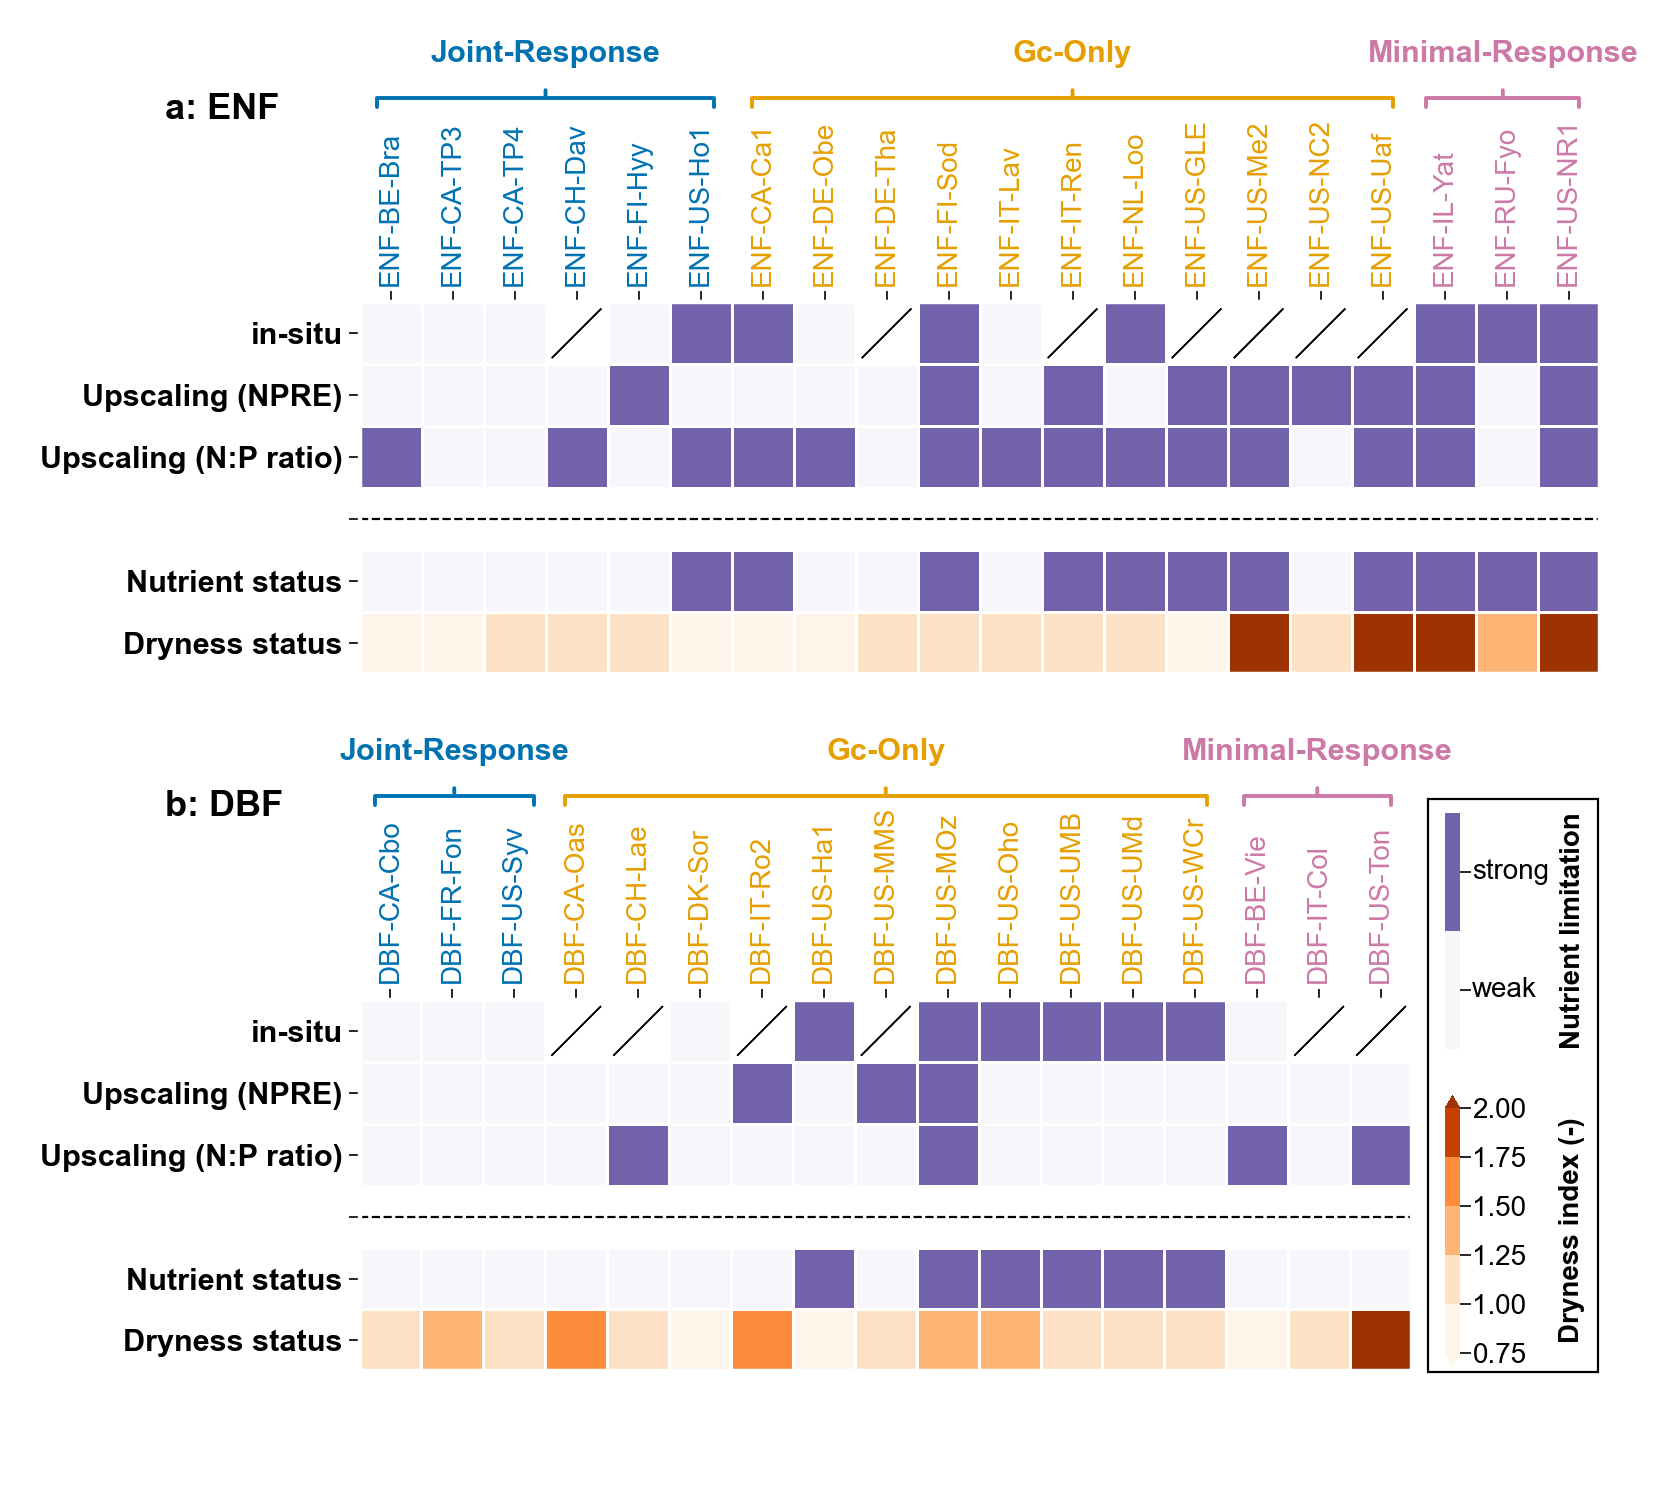

In [6]:
fig_w,fig_h = 9, 9
width_new   = 4
height_new  = width_new
fig = plt.figure(figsize=(width_new,height_new),dpi=200)

shape = (9,20)
ax1 = plt.subplot2grid(shape, loc=(0,0), colspan=20,rowspan=4)
ax2 = plt.subplot2grid(shape, (5,0), colspan=17,rowspan=4)
ax3 = plt.subplot2grid(shape, (4,17),colspan=3,rowspan=5)

NP_cols = ['NP_limitation_insitu','NP_limitation_NPRE','NP_limitation_ratio','final']
DI_cols = ['DI_Rnet']

# ---------- ENF -------------
data_ENF,nan_mask_ENF,row_labels_ENF,col_labels_ENF,col_colors_ENF = pre_process(['ENF'],df)

# nutrient 
data1 = data_ENF.copy()
data1[~data1.index.isin(NP_cols)] = np.nan
im1 = plot_nutrient_heatmap_purple(data1,ax1)
# dryness 
data2  = data_ENF.copy()
data2[~data2.index.isin(DI_cols)] = np.nan
im2 = plot_dryness_heatmap_yellow(data2,ax1)

forward_slash(np.argwhere(np.isnan(data_ENF.transpose().values)&(nan_mask_ENF==True)), 
              ax=ax1, scale=0.8, color="black",alpha=1,linewidths=0.3)

# Major ticks
n_y,n_x = data_ENF.shape
ax1.set_xticks(np.arange(0, n_x, 1), labels=col_labels_ENF,fontsize=fontsize-1.5,rotation=90)
ax1.set_yticks(np.arange(0, n_y, 1), labels=row_labels_ENF,fontsize=fontsize-1,fontweight='bold')

# ---------- DBF -------------
data_DBF,nan_mask_DBF,row_labels_DBF,col_labels_DBF,col_colors_DBF = pre_process(['DBF'],df)

# nutrient 
data1 = data_DBF.copy()
data1[~data1.index.isin(NP_cols)] = np.nan
im1 = plot_nutrient_heatmap_purple(data1,ax2)
# dryness 
data2  = data_DBF.copy()
data2[~data2.index.isin(DI_cols)] = np.nan
im2 = plot_dryness_heatmap_yellow(data2,ax2)

forward_slash(np.argwhere(np.isnan(data_DBF.transpose().values)&(nan_mask_DBF==True)), 
              ax=ax2, scale=0.8, color="black",alpha=1,linewidths=0.3)

# Major ticks
n_y,n_x = data_DBF.shape
ax2.set_xticks(np.arange(0, n_x, 1), labels=col_labels_DBF,fontsize=fontsize-1.5,rotation=90)
ax2.set_yticks(np.arange(0, n_y, 1), labels=row_labels_DBF,fontsize=fontsize-1,fontweight='bold')


# ---------- common setting -----------
col_colors_list = [col_colors_ENF,col_colors_DBF]
n_x_list = [len(col_colors_ENF),len(col_colors_DBF)]
for i,ax in enumerate([ax1,ax2]):
    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,labeltop=True, labelbottom=False)
    # # Minor ticks
    # ax.set_xticks(np.arange(-.5, n_x_list[i], 1), minor=True)
    # ax.set_yticks(np.arange(-.5, n_y, 1), minor=True)
    # # Gridlines based on minor ticks
    # ax.grid(which='minor', color='w', linestyle='-', linewidth=0.7)
    # Remove minor ticks
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.spines[:].set_color('white')
    # set xticklabel colors
    for j, tick in enumerate(ax.get_xticklabels()):
        tick.set_color(col_colors_list[i][j])
    
    ax.axhline(y = 3, color = 'black', linestyle = '--',linewidth=0.4,alpha=1) 

for ax in [ax1, ax2, ax3]:
    ax.tick_params(width=0.3, length=2)
    ax.tick_params(axis='x', pad=1) 
    ax.tick_params(axis='y', pad=1) 

# ------------- legend ---------------
width = 0.96
square = mpatches.Rectangle((0.99-width, 0.12), width, 0.85, fill=False, edgecolor='black', 
                            transform=ax3.transAxes,clip_on=False,linewidth=0.4)  # lower-left corner, width, height

ax3.add_patch(square)


ax3.tick_params(left=False,bottom=False,labelleft=False, labelbottom=False)
ax3.spines['left'].set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['right'].set_visible(False)

cax2  = ax3.inset_axes([0.13, 0.6, 0.08, 0.35])
cbar2 = fig.colorbar(im1,ax=ax3,cax=cax2,aspect=60,shrink=0.4,extend=None,
                     orientation='vertical',pad=0,ticks=[0.5, 1.5]) 

for tick in cbar2.ax.yaxis.get_minor_ticks():
    tick.tick1line.set_markersize(0)
    tick.tick2line.set_markersize(0)

cbar2.outline.set_visible(False)
cbar2.ax.set_yticks([0.5,1.5],labels=['weak','strong'], fontsize=fontsize-1.5,
                    rotation=0,va='center')
cbar2.ax.tick_params(labelsize=fontsize-1.5,width=0.3, length=2,pad=0.3)
cbar2.ax.set_ylabel('Nutrient limitation', rotation=90, fontsize=fontsize-1.5,labelpad=2,fontweight='bold') # va="bottom",


cax2  = ax3.inset_axes([0.13, 0.13, 0.08, 0.4])
cbar2 = fig.colorbar(im2,ax=ax3,cax=cax2,aspect=60,shrink=0.4,extend='both',
                     orientation='vertical',pad=0) 
cbar2.outline.set_visible(False)
cbar2.ax.tick_params(labelsize=fontsize-1.5,width=0.3, length=2,pad=0.3)
cbar2.ax.set_ylabel('Dryness index (-)', rotation=90, va="bottom",
                    fontsize=fontsize-1.5,labelpad=10.5,fontweight='bold')


# ---------- denote patterns ---------------
y_loc = 1.55
label_fontsize = fontsize-1
y_dis = 0.08
lw = 0.7
# Updating the 'Joint-driven' annotation
ax1.annotate('Joint-Response', xy=(0.15, y_loc), xytext=(0.15, y_loc + y_dis), xycoords='axes fraction', 
            fontsize=label_fontsize, ha='center', va='bottom', color=cluster_color_dic[1], fontweight='bold',
            arrowprops=dict(arrowstyle='-[, widthB=5.5, lengthB=0.3', lw=lw, color=cluster_color_dic[1]),
            textcoords='axes fraction')

ax1.annotate('Gc-Only', xy=(0.575, y_loc), xytext=(0.575, y_loc + y_dis), xycoords='axes fraction', 
            fontsize=label_fontsize, ha='center', va='bottom',color=cluster_color_dic[2],fontweight='bold',
            arrowprops=dict(arrowstyle='-[, widthB=10.5, lengthB=0.3', lw=lw, color=cluster_color_dic[2]),
            textcoords='axes fraction')

ax1.annotate('Minimal-Response', xy=(0.922, y_loc), xytext=(0.922, y_loc+ y_dis), xycoords='axes fraction', 
            fontsize=label_fontsize, ha='center', va='bottom',color=cluster_color_dic[3],fontweight='bold',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=0.3', lw=lw, color=cluster_color_dic[3]),
            textcoords='axes fraction')

ax2.annotate('Joint-Response', xy=(0.09, y_loc), xytext=(0.09, y_loc+y_dis), xycoords='axes fraction', 
            fontsize=label_fontsize, ha='center', va='bottom',color=cluster_color_dic[1],fontweight='bold',
            arrowprops=dict(arrowstyle='-[, widthB=2.6, lengthB=0.3', lw=lw, color=cluster_color_dic[1]),
            textcoords='axes fraction')


ax2.annotate('Gc-Only', xy=(0.5, y_loc), xytext=(0.5, y_loc + y_dis), xycoords='axes fraction', 
            fontsize=label_fontsize, ha='center', va='bottom',color=cluster_color_dic[2],fontweight='bold',
            arrowprops=dict(arrowstyle='-[, widthB=10.5, lengthB=0.3', lw=lw, color=cluster_color_dic[2]),
            textcoords='axes fraction')


ax2.annotate('Minimal-Response', xy=(0.91, y_loc), xytext=(0.91, y_loc + y_dis), xycoords='axes fraction', 
            fontsize=label_fontsize, ha='center', va='bottom',color=cluster_color_dic[3],fontweight='bold',
            arrowprops=dict(arrowstyle='-[, widthB=2.4, lengthB=0.3', lw=lw, color=cluster_color_dic[3]),
            textcoords='axes fraction')

seq = ['a: ENF','b: DBF']
for i,ax in enumerate([ax1,ax2]):
    ax.annotate(seq[i],xy=(-35,100), xycoords='axes points',fontweight='bold',fontsize=fontsize)

plt.tight_layout()